# Quickstart: DEAP EEG Emotion Recognition Reproduction

Reproduces Mouazen et al. 2025 (Sensors 25(6):1827) preprocessing + feature + model pipeline.

Before running: place `s01.dat`...`s32.dat` (DEAP preprocessed release) under `../data/`.


In [2]:
%pip install PyWavelets

   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ------- -------------------------------- 0.8/4.2 MB 11.2 MB/s eta 0:00:01
   -------------------------------- ------- 3.4/4.2 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 4.2/4.2 MB 12.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [11]:
import sys, os
sys.path.append(os.path.abspath(".."))

from utils import set_seed
from dataset import load_all_subjects, binarize_labels
from preprocessing.preprocessing import PreprocessConfig, run_pipeline
from features.feature_extraction import extract_features_dataset
from models.models import build_random_forest
from evaluation.evaluate import plot_confusion_matrix, plot_tsne, plot_feature_importance

set_seed(42)

# Verify the data folder exists before loading subjects.
data_dir = os.path.abspath("../data")
if not os.path.exists(data_dir):
    raise FileNotFoundError("Please place s01.dat...s32.dat under ../data/ before running the notebook.")
print("Data directory:", data_dir)


Data directory: c:\Users\User\Downloads\eeg-emotion-detection\project\data


## 1. Load a few subjects (use all 32 for the full reproduction)

In [12]:
eeg, labels, subj = load_all_subjects(data_dir, subject_ids=[1, 2, 3])
print("EEG:", eeg.shape, "Labels:", labels.shape)


EEG: (120, 32, 8064) Labels: (120, 4)


## 2. Preprocess: band-pass -> ICA -> baseline removal -> normalize -> window

In [13]:
cfg = PreprocessConfig()
winds = run_pipeline(eeg, cfg, use_ica=True)
windows = winds
print("Windows:", windows.shape)


c:\Users\User\anaconda3\envs\streamlitenv\Lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
c:\Users\User\anaconda3\envs\streamlitenv\Lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
c:\Users\User\anaconda3\envs\streamlitenv\Lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
c:\Users\User\anaconda3\envs\streamlitenv\Lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Windows: (120, 29, 32, 512)


## 3. Feature extraction: PSD + Differential Entropy + Hjorth + Wavelet + STFT

In [ ]:
X = extract_features_dataset(windows)
label_dict = binarize_labels(labels)
y = label_dict["valence"].repeat(windows.shape[1])
print("Feature matrix:", X.shape, "Labels:", y.shape)


Feature matrix: (3480, 640) Labels: (3480,)


## 4. Train a classical model (Random Forest) and evaluate

Saved figure: c:\Users\User\Downloads\eeg-emotion-detection\project\figures\confusion_matrix.png


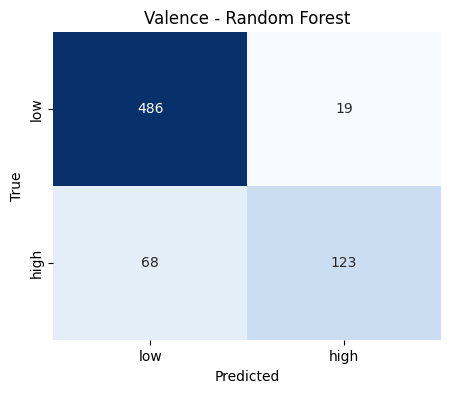

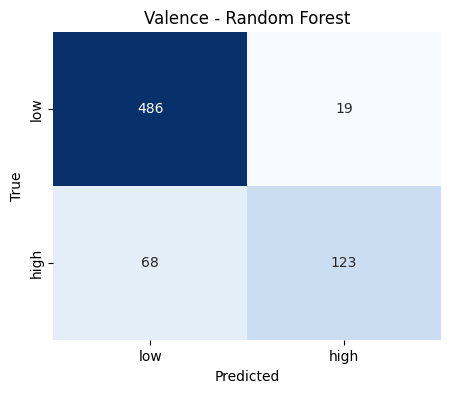

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

clf = build_random_forest()
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

plot_confusion_matrix(y_test, preds, class_names=["low", "high"], title="Valence - Random Forest")


## 5. Visualize the feature space (t-SNE) and feature importance

Saved figure: c:\Users\User\Downloads\eeg-emotion-detection\project\figures\tsne.png
Saved figure: c:\Users\User\Downloads\eeg-emotion-detection\project\figures\feature_importance.png


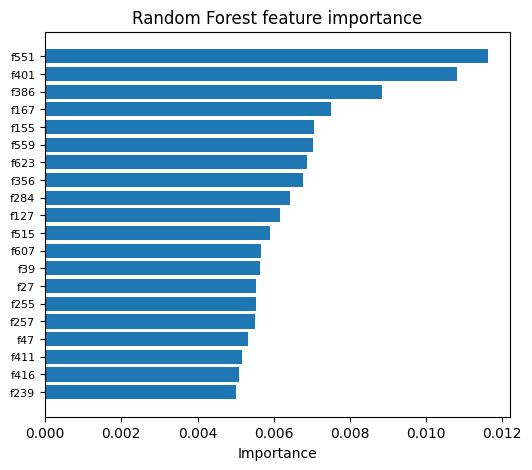

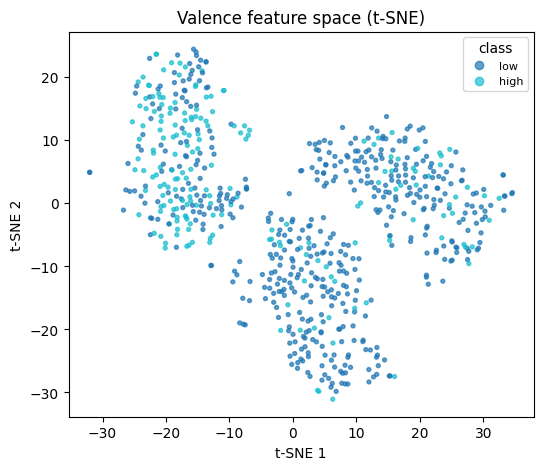

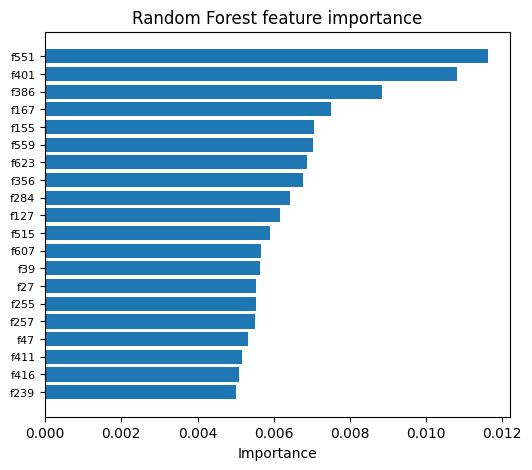

In [10]:
plot_tsne(X_test, y_test, class_names=["low", "high"], title="Valence feature space (t-SNE)")
plot_feature_importance(clf, title="Random Forest feature importance")
